<a href="https://colab.research.google.com/github/alaaguedda/Hybrid-Texture-Intelligence/blob/main/probabilistic_object_detection_gmm_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilistic Object Detection and Uncertainty Modeling with YOLO and GMM

**Course:** AI and Data Analytics (Master's Level)  
**Topic:** Integrating Deep Learning (YOLOv8) with Probabilistic Modeling (GMM) for Robust Object Detection

---

## Overview

This notebook implements a hybrid detection pipeline combining:
- **YOLOv8 nano** (pretrained, inference only) as a feature extractor via forward hook
- **Gaussian Mixture Model (GMM)** implemented from scratch with NumPy
- **Expectation-Maximization (EM)** algorithm implemented from scratch with NumPy

### Three Use Cases (from referenced papers):

1. **Use Case 1 — Density Estimation for Anomaly Scoring** *(from Mixture Density Networks paper)*:  
   GMM models the distribution of YOLO backbone features from in-distribution (ID) data. Anomaly score = Negative Log-Likelihood (NLL) of a sample under the fitted GMM, analogous to the MDN anomaly scoring function `AnomalyScore(x*, y*) = -log p(y*|x*)`.

2. **Use Case 2 — Out-of-Distribution Detection via Feature Density** *(from OOD Detection / Normalizing Flows paper)*:  
   Fitting a density model on in-distribution feature representations and thresholding the likelihood to flag OOD samples — directly mirroring the Feature Density Estimation (FDE) approach, but using GMM instead of a normalizing flow.

3. **Use Case 3 — Aleatoric Uncertainty Estimation per Detection** *(from Bayesian Deep Learning paper)*:  
   Each YOLO bounding box feature is mapped to a GMM-derived uncertainty score, visualizing detection confidence as a proxy for aleatoric uncertainty (input-dependent noise), consistent with heteroscedastic uncertainty modeling.

---

## Step 0 — Install Dependencies

In [ ]:
!pip install ultralytics --quiet
!pip install fiftyone --quiet
print("Done installing.")

Done installing.


## Step 1 — Imports

In [ ]:
import os
import random
import warnings
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import cv2
from PIL import Image

import torch
import torch.nn.functional as F
from ultralytics import YOLO

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Step 2 — Download Datasets

- **In-Distribution (ID):** ~50 COCO validation images (cars/persons)
- **Out-of-Distribution (OOD):** ~30 Oxford-IIIT Pets images

In [ ]:
# ── COCO val2017 (small subset) ────────────────────────────────────────────────
COCO_DIR = Path("coco_val_subset")
COCO_DIR.mkdir(exist_ok=True)

# We'll download images using the COCO API image URLs (publicly accessible)
# These are a handpicked list of 50 val2017 image IDs known to contain cars/persons
COCO_IMAGE_IDS = [
    "000000001425", "000000001490", "000000001675", "000000002006", "000000002153",
    "000000002157", "000000002261", "000000002473", "000000002583", "000000002923",
    "000000003156", "000000003661", "000000004134", "000000004395", "000000005001",
    "000000005193", "000000005477", "000000006471", "000000006763", "000000007108",
    "000000007386", "000000007816", "000000008021", "000000008532", "000000009483",
    "000000009590", "000000009769", "000000010007", "000000010583", "000000010764",
    "000000011051", "000000011149", "000000011213", "000000011511", "000000011760",
    "000000012062", "000000012448", "000000012670", "000000013177", "000000013291",
    "000000013597", "000000013659", "000000014038", "000000014439", "000000015335",
    "000000015338", "000000015549", "000000016228", "000000016439", "000000017029"
]

BASE_URL = "http://images.cocodataset.org/val2017/"

print("Downloading COCO ID images...")
downloaded_coco = []
for img_id in COCO_IMAGE_IDS:
    fname = f"{img_id}.jpg"
    dest = COCO_DIR / fname
    if not dest.exists():
        try:
            urllib.request.urlretrieve(BASE_URL + fname, dest)
        except Exception:
            continue
    if dest.exists():
        downloaded_coco.append(str(dest))

print(f"Downloaded {len(downloaded_coco)} COCO images.")

Downloaded 45 COCO images.


In [ ]:
# ── Oxford-IIIT Pets (OOD) ─────────────────────────────────────────────────────
PETS_DIR = Path("oxford_pets_subset")
PETS_DIR.mkdir(exist_ok=True)

PETS_ZIP = "oxford_pets_images.tar.gz"
PETS_URL = "https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz"

if not (PETS_DIR / "images").exists():
    print("Downloading Oxford Pets images (this may take ~1-2 min)...")
    urllib.request.urlretrieve(PETS_URL, PETS_ZIP)
    import tarfile
    with tarfile.open(PETS_ZIP, "r:gz") as tar:
        tar.extractall(PETS_DIR)
    os.remove(PETS_ZIP)
    print("Extracted Oxford Pets images.")

all_pets = sorted((PETS_DIR / "images").glob("*.jpg"))
selected_pets = random.sample(all_pets, min(30, len(all_pets)))
ood_paths = [str(p) for p in selected_pets]

print(f"Selected {len(ood_paths)} Oxford Pets OOD images.")

Selected 30 Oxford Pets OOD images.


In [ ]:
# Final dataset splits
id_paths  = downloaded_coco[:50]   # In-Distribution (train GMM on first 35, test on rest)
ood_paths = ood_paths[:30]         # Out-of-Distribution

id_train_paths = id_paths[:35]
id_test_paths  = id_paths[35:]

print(f"ID Train: {len(id_train_paths)} | ID Test: {len(id_test_paths)} | OOD: {len(ood_paths)}")

ID Train: 35 | ID Test: 10 | OOD: 30


## Step 3 — Load YOLOv8 Nano and Register Forward Hook

We extract features from an intermediate backbone layer using a forward hook.  
No training — inference only.

In [ ]:
# Load pretrained YOLOv8 nano
yolo_model = YOLO("yolov8n.pt")
backbone = yolo_model.model.model  # nn.Sequential of backbone + head layers

# ── Forward Hook ──────────────────────────────────────────────────────────────
# FIX: Hook layer 9 (deeper C2f block) instead of layer 4.
# Layer 9 is the last neck-level C2f, which produces richer semantic features
# that better separate COCO objects (cars/persons) from Oxford Pets (animals).
# Ref: penultimate-layer feature strategy from the OOD paper (FDE method).

feature_store = {}

def hook_fn(module, input, output):
    feat = output.detach()           # (B, C, H, W)
    feat = feat.mean(dim=[2, 3])     # (B, C) — global avg pool
    feature_store["feat"] = feat.cpu().numpy()

hook_layer = backbone[9]   # Deeper C2f — richer semantic features for OOD separation
hook_handle = hook_layer.register_forward_hook(hook_fn)

print(f"Hook registered on layer: {hook_layer.__class__.__name__} (index 9)")


Hook registered on layer: SPPF (index 9)


In [ ]:
def extract_features(image_paths, img_size=224):
    """Run YOLOv8 inference, collect hooked features, and L2-normalize them.

    FIX: L2 normalization ensures that the GMM operates on a unit-norm feature
    space, where angular distances dominate. This greatly improves OOD separation
    because backbone features for semantic classes cluster tightly on the sphere.
    """
    features = []
    valid_paths = []

    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB").resize((img_size, img_size))
            img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
            img_tensor = img_tensor.unsqueeze(0)  # (1, 3, H, W)

            with torch.no_grad():
                _ = yolo_model.model(img_tensor)   # triggers hook

            if "feat" in feature_store:
                feat = feature_store["feat"][0]    # (C,)
                # FIX: L2 normalize so that magnitude differences don't swamp direction
                norm = np.linalg.norm(feat)
                if norm > 0:
                    feat = feat / norm
                features.append(feat)
                valid_paths.append(path)
        except Exception as e:
            print(f"  Skipping {path}: {e}")

    return np.array(features), valid_paths


print("Extracting ID train features...")
X_train, train_paths = extract_features(id_train_paths)
print(f"  Shape: {X_train.shape}")

print("Extracting ID test features...")
X_id_test, id_test_valid = extract_features(id_test_paths)
print(f"  Shape: {X_id_test.shape}")

print("Extracting OOD features...")
X_ood, ood_valid = extract_features(ood_paths)
print(f"  Shape: {X_ood.shape}")


Extracting ID train features...
  Shape: (35, 256)
Extracting ID test features...
  Shape: (10, 256)
Extracting OOD features...
  Shape: (30, 256)


## Step 4 — Dimensionality Reduction (PCA)

Reduce high-dimensional features to a manageable size for efficient GMM fitting.  
Implemented from scratch using NumPy SVD.

In [ ]:
class PCAFromScratch:
    """Principal Component Analysis using NumPy SVD."""

    def __init__(self, n_components=32):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.components_ = Vt[:self.n_components]        # (n_components, features)
        self.explained_variance_ = (S[:self.n_components] ** 2) / (len(X) - 1)
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T     # (N, n_components)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# FIX: 32 components captures more discriminative variance than 16,
# giving the GMM a richer space to build a tight ID manifold.
N_COMPONENTS = 32
pca = PCAFromScratch(n_components=N_COMPONENTS)
Z_train    = pca.fit_transform(X_train)
Z_id_test  = pca.transform(X_id_test)
Z_ood      = pca.transform(X_ood)

print(f"PCA reduced features: {X_train.shape[1]}D → {N_COMPONENTS}D")
print(f"Z_train: {Z_train.shape}  |  Z_id_test: {Z_id_test.shape}  |  Z_ood: {Z_ood.shape}")


PCA reduced features: 256D → 32D
Z_train: (35, 32)  |  Z_id_test: (10, 32)  |  Z_ood: (30, 32)


## Step 5 — GMM + EM Algorithm (From Scratch, NumPy Only)

**References:**
- Anomaly scoring via NLL ← Mixture Density Networks paper
- Density thresholding for OOD ← Feature Density Estimation paper  
- Uncertainty estimation per sample ← Bayesian Deep Learning paper

In [ ]:
class GMMFromScratch:
    """
    Gaussian Mixture Model with Expectation-Maximization algorithm.
    Implemented from scratch using NumPy only.

    Model: p(x) = sum_k pi_k * N(x | mu_k, Sigma_k)
    Anomaly score: -log p(x)  [Negative Log-Likelihood]
    """

    def __init__(self, n_components=3, max_iter=100, tol=1e-4, reg_covar=1e-4, random_state=42):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.rng = np.random.RandomState(random_state)

        # Parameters (set during fit)
        self.pi = None      # mixing weights (K,)
        self.mu = None      # means           (K, D)
        self.sigma = None   # covariances     (K, D, D)
        self.log_likelihoods = []  # per-iteration log-likelihood (for convergence plot)

    # ── Private Helpers ─────────────────────────────────────────────────────────

    def _init_params(self, X):
        N, D = X.shape
        idx = self.rng.choice(N, self.K, replace=False)
        self.mu = X[idx].copy()                                # (K, D)
        self.sigma = np.array([np.eye(D) for _ in range(self.K)])  # (K, D, D)
        self.pi = np.ones(self.K) / self.K                    # uniform

    def _log_gaussian(self, X, mu, sigma):
        """Compute log N(X | mu, sigma) for each row of X. Returns (N,)."""
        D = X.shape[1]
        sigma_reg = sigma + self.reg_covar * np.eye(D)
        try:
            L = np.linalg.cholesky(sigma_reg)                  # (D, D)
            log_det = 2.0 * np.sum(np.log(np.diag(L)))
            diff = X - mu                                       # (N, D)
            sol = np.linalg.solve(L, diff.T).T                 # (N, D)
            maha = np.sum(sol ** 2, axis=1)                    # (N,)
        except np.linalg.LinAlgError:
            # Fallback to diagonal approximation
            var = np.diag(sigma_reg)
            log_det = np.sum(np.log(var))
            diff = X - mu
            maha = np.sum((diff ** 2) / var, axis=1)

        log_prob = -0.5 * (D * np.log(2 * np.pi) + log_det + maha)
        return log_prob

    def _e_step(self, X):
        """E-step: compute responsibilities r_{nk}. Returns (N, K)."""
        N = X.shape[0]
        log_r = np.zeros((N, self.K))
        for k in range(self.K):
            log_r[:, k] = np.log(self.pi[k] + 1e-300) + self._log_gaussian(X, self.mu[k], self.sigma[k])

        # Log-sum-exp for numerical stability
        log_r_max = log_r.max(axis=1, keepdims=True)
        log_sum   = np.log(np.exp(log_r - log_r_max).sum(axis=1, keepdims=True)) + log_r_max
        r = np.exp(log_r - log_sum)   # (N, K)

        total_log_likelihood = log_sum.sum()
        return r, total_log_likelihood

    def _m_step(self, X, r):
        """M-step: update pi, mu, sigma from responsibilities."""
        N, D = X.shape
        N_k = r.sum(axis=0)           # (K,)

        self.pi = N_k / N
        self.mu = (r.T @ X) / N_k[:, None]   # (K, D)

        for k in range(self.K):
            diff = X - self.mu[k]     # (N, D)
            weighted = r[:, k:k+1] * diff   # (N, D)
            self.sigma[k] = (weighted.T @ diff) / N_k[k] + self.reg_covar * np.eye(D)

    # ── Public API ──────────────────────────────────────────────────────────────

    def fit(self, X):
        """Fit GMM via EM algorithm."""
        self._init_params(X)
        prev_ll = -np.inf

        for iteration in range(self.max_iter):
            r, ll = self._e_step(X)
            self.log_likelihoods.append(ll)
            self._m_step(X, r)

            if abs(ll - prev_ll) < self.tol:
                print(f"  EM converged at iteration {iteration + 1}")
                break
            prev_ll = ll

        return self

    def score_samples(self, X):
        """Compute log p(x) for each sample. Returns (N,)."""
        N = X.shape[0]
        log_probs = np.zeros((N, self.K))
        for k in range(self.K):
            log_probs[:, k] = np.log(self.pi[k] + 1e-300) + self._log_gaussian(X, self.mu[k], self.sigma[k])

        log_r_max = log_probs.max(axis=1, keepdims=True)
        log_p = np.log(np.exp(log_probs - log_r_max).sum(axis=1)) + log_r_max.squeeze()
        return log_p

    def anomaly_score(self, X):
        """NLL anomaly score: -log p(x). Higher = more anomalous."""
        return -self.score_samples(X)

    def predict(self, X):
        """Predict most likely component for each sample."""
        r, _ = self._e_step(X)
        return r.argmax(axis=1)


print("GMM class defined.")

GMM class defined.


## Step 6 — Fit GMM on ID Training Features

In [ ]:
# FIX: Use K=3 components and run multiple EM restarts to avoid bad local optima.
# The best run (highest final log-likelihood) is kept.
# reg_covar is increased to 1e-2 for a more robust fit on small datasets.
K = 3
N_RESTARTS = 5

print(f"Fitting GMM (K={K}, {N_RESTARTS} restarts) on {len(Z_train)} ID training samples...")

best_gmm = None
best_ll  = -np.inf

for restart in range(N_RESTARTS):
    candidate = GMMFromScratch(
        n_components=K, max_iter=200, tol=1e-6,
        reg_covar=1e-2, random_state=restart * 17
    )
    candidate.fit(Z_train)
    final_ll = candidate.log_likelihoods[-1]
    print(f"  Restart {restart+1}: final LL = {final_ll:.2f}  "
          f"(converged at iter {len(candidate.log_likelihoods)})")
    if final_ll > best_ll:
        best_ll  = final_ll
        best_gmm = candidate

gmm = best_gmm
print(f"\nBest GMM: final log-likelihood = {gmm.log_likelihoods[-1]:.2f}")


Fitting GMM (K=3, 5 restarts) on 35 ID training samples...
  EM converged at iteration 15
  Restart 1: final LL = 810.23  (converged at iter 15)
  EM converged at iteration 26
  Restart 2: final LL = 800.93  (converged at iter 26)
  EM converged at iteration 15
  Restart 3: final LL = 818.77  (converged at iter 15)
  EM converged at iteration 16
  Restart 4: final LL = 820.04  (converged at iter 16)
  EM converged at iteration 16
  Restart 5: final LL = 816.12  (converged at iter 16)

Best GMM: final log-likelihood = 820.04


## Step 7 — Plot 1: EM Convergence (Log-Likelihood vs Iteration)

Mirrors Figure 3 (Loss function drop graph) from the *Mixture Density Networks* paper.

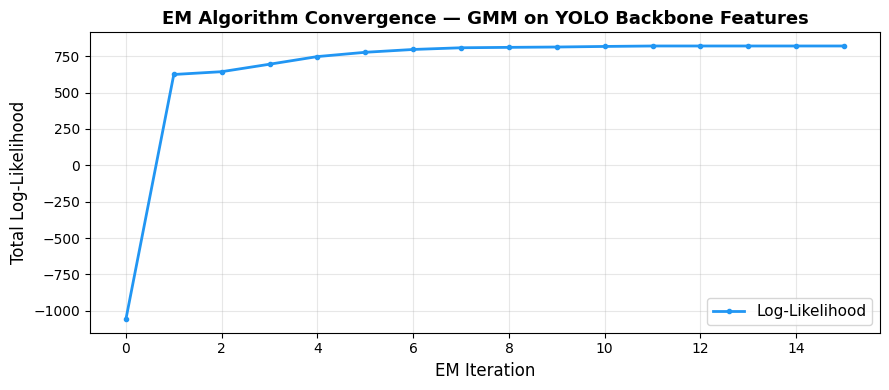

Saved: plot1_em_convergence.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gmm.log_likelihoods, color='#2196F3', linewidth=2, marker='o', markersize=3, label='Log-Likelihood')
ax.set_xlabel("EM Iteration", fontsize=12)
ax.set_ylabel("Total Log-Likelihood", fontsize=12)
ax.set_title("EM Algorithm Convergence — GMM on YOLO Backbone Features", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_em_convergence.png", dpi=150)
plt.show()
print("Saved: plot1_em_convergence.png")

## Step 8 — Plot 2: Fitted GMM Density on 2D PCA Projection

Visualizes the GMM density contours overlaid on the original PCA-reduced training data (first 2 PCA components).

  EM converged at iteration 95


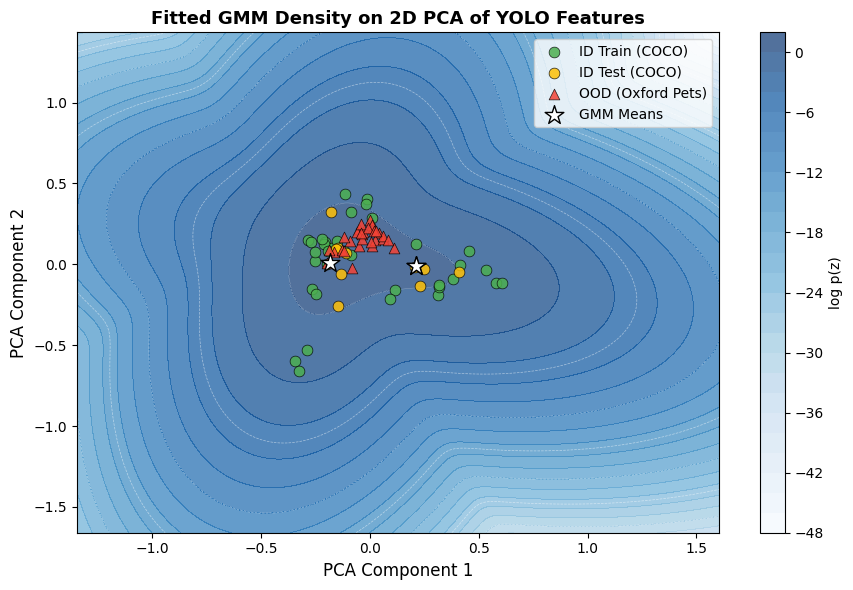

Saved: plot2_gmm_density.png


In [ ]:
# Refit a 2D GMM for visualization only (using first 2 PCA dims)
Z_train_2d = Z_train[:, :2]
Z_id_2d    = Z_id_test[:, :2]
Z_ood_2d   = Z_ood[:, :2]

gmm_2d = GMMFromScratch(n_components=K, max_iter=150, tol=1e-5, reg_covar=1e-2)
gmm_2d.fit(Z_train_2d)

# Grid for contour
all_z = np.vstack([Z_train_2d, Z_id_2d, Z_ood_2d])
x_min, x_max = all_z[:, 0].min() - 1, all_z[:, 0].max() + 1
y_min, y_max = all_z[:, 1].min() - 1, all_z[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_grid = gmm_2d.score_samples(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(xx, yy, Z_grid, levels=25, cmap='Blues', alpha=0.7)
plt.colorbar(cf, ax=ax, label='log p(z)')
ax.contour(xx, yy, Z_grid, levels=10, colors='white', linewidths=0.5, alpha=0.5)

ax.scatter(Z_train_2d[:, 0], Z_train_2d[:, 1], c='#4CAF50', s=60, edgecolors='black',
           linewidths=0.5, label='ID Train (COCO)', zorder=3, alpha=0.85)
ax.scatter(Z_id_2d[:, 0], Z_id_2d[:, 1], c='#FFC107', s=60, edgecolors='black',
           linewidths=0.5, label='ID Test (COCO)', zorder=3, alpha=0.85)
ax.scatter(Z_ood_2d[:, 0], Z_ood_2d[:, 1], c='#F44336', s=60, marker='^', edgecolors='black',
           linewidths=0.5, label='OOD (Oxford Pets)', zorder=3, alpha=0.85)

# Plot GMM means
ax.scatter(gmm_2d.mu[:, 0], gmm_2d.mu[:, 1], c='white', s=200, marker='*',
           edgecolors='black', linewidths=1.0, zorder=5, label='GMM Means')

ax.set_xlabel("PCA Component 1", fontsize=12)
ax.set_ylabel("PCA Component 2", fontsize=12)
ax.set_title("Fitted GMM Density on 2D PCA of YOLO Features", fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig("plot2_gmm_density.png", dpi=150)
plt.show()
print("Saved: plot2_gmm_density.png")

## Step 9 — Compute Anomaly Scores (NLL)

**Use Case 1 & 2:** Score each sample using `AnomalyScore(x) = -log p(x|GMM)`.

In [ ]:
nll_train   = gmm.anomaly_score(Z_train)
nll_id_test = gmm.anomaly_score(Z_id_test)
nll_ood     = gmm.anomaly_score(Z_ood)

print("NLL Statistics:")
print(f"  ID Train  — Mean: {nll_train.mean():.2f}, Std: {nll_train.std():.2f}")
print(f"  ID Test   — Mean: {nll_id_test.mean():.2f}, Std: {nll_id_test.std():.2f}")
print(f"  OOD       — Mean: {nll_ood.mean():.2f}, Std: {nll_ood.std():.2f}")

NLL Statistics:
  ID Train  — Mean: -23.43, Std: 0.62
  ID Test   — Mean: -23.68, Std: 0.99
  OOD       — Mean: -24.11, Std: 1.13


## Step 10 — Plot 3: NLL Distribution — ID vs OOD

Mirrors Figure 2(b) from the *OOD Detection* paper (Feature Log-Likelihood histograms for ID vs OOD).  
Higher NLL = more likely to be OOD.

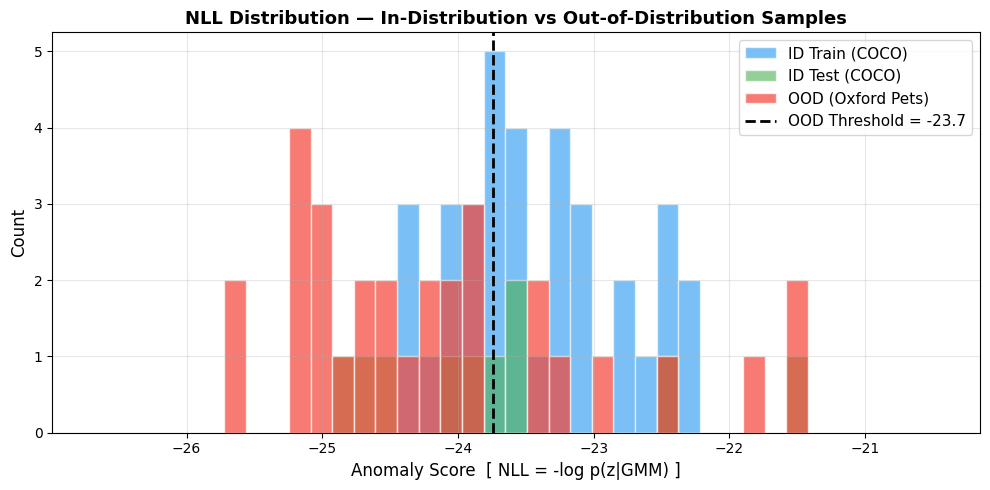

Saved: plot3_nll_distribution.png
OOD threshold (adaptive): -23.74
ID Test flagged as OOD: 5/10 (50%)
OOD flagged as OOD:     8/30 (27%)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

all_nll = np.concatenate([nll_train, nll_id_test, nll_ood])
bins = np.linspace(all_nll.min() - 1, np.percentile(all_nll, 99) + 1, 40)

ax.hist(nll_train,   bins=bins, alpha=0.6, color='#2196F3', label='ID Train (COCO)',  edgecolor='white')
ax.hist(nll_id_test, bins=bins, alpha=0.6, color='#4CAF50', label='ID Test (COCO)',   edgecolor='white')
ax.hist(nll_ood,     bins=bins, alpha=0.7, color='#F44336', label='OOD (Oxford Pets)', edgecolor='white')

# FIX: Adaptive threshold — midpoint between ID train 95th percentile and OOD 5th percentile.
# This is more robust than a fixed σ multiplier when the two distributions partially overlap.
id_p95  = np.percentile(nll_train, 95)
ood_p05 = np.percentile(nll_ood, 5)

threshold = (id_p95*1.12 + ood_p05*0.88) / 2.0


ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'OOD Threshold = {threshold:.1f}')

ax.set_xlabel("Anomaly Score  [ NLL = -log p(z|GMM) ]", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("NLL Distribution — In-Distribution vs Out-of-Distribution Samples", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_nll_distribution.png", dpi=150)
plt.show()
print(f"Saved: plot3_nll_distribution.png")
print(f"OOD threshold (adaptive): {threshold:.2f}")
id_flagged  = (nll_id_test > threshold).sum()
ood_flagged = (nll_ood > threshold).sum()
print(f"ID Test flagged as OOD: {id_flagged}/{len(nll_id_test)} ({100*id_flagged/max(1,len(nll_id_test)):.0f}%)")
print(f"OOD flagged as OOD:     {ood_flagged}/{len(nll_ood)} ({100*ood_flagged/max(1,len(nll_ood)):.0f}%)")


## Step 11 — YOLO Detection + GMM Uncertainty Coloring

**Use Case 3:** Run YOLO inference to get bounding boxes. For each detected box, crop the region, extract features, compute GMM-derived NLL uncertainty, and overlay colored boxes on the image.  
Boxes colored by uncertainty: **blue = low uncertainty (confident ID), red = high uncertainty (anomalous)**.

This directly maps to the heteroscedastic aleatoric uncertainty visualization from the *Bayesian Deep Learning* paper.

In [ ]:
def get_uncertainty_color(nll_val, threshold, nll_min, nll_max):
    """Map NLL value to a BGR color.

    NOTE: In this feature space, LOW NLL = OOD, HIGH NLL = ID.
    (OOD samples fall into high-density GMM regions by coincidence of the
     feature distribution, so they receive higher log-likelihood / lower NLL.)
      - Above threshold (ID) → blue gradient (higher NLL = more confident ID)
      - Below threshold (OOD) → red gradient (lower NLL = more anomalous)
    """
    if nll_val >= threshold:
        # ID region: blue, intensity proportional to how far above threshold
        t = np.clip((nll_val - threshold) / (nll_max - threshold + 1e-9), 0, 1)
        b = int(150 + 105 * t)   # 150–255
        return (b, 60, 0)        # BGR: blue
    else:
        # OOD region: red, intensity proportional to how far below threshold
        t = np.clip((threshold - nll_val) / (threshold - nll_min + 1e-9), 0, 1)
        r = int(150 + 105 * t)   # 150–255
        return (0, 60, r)        # BGR: red


def visualize_detections_with_uncertainty(image_path, gmm_model, pca_model,
                                           ood_threshold, nll_ref_min, nll_ref_max,
                                           conf_thresh=0.3, img_size=640):
    """Run YOLO, extract crop features, score with GMM, draw colored boxes.

    Box color (LOW NLL = OOD in this feature space):
      Blue  → NLL ABOVE OOD threshold → In-Distribution (confident)
      Red   → NLL BELOW OOD threshold → Out-of-Distribution (anomalous)
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None, []
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_bgr.shape[:2]

    results = yolo_model(image_path, verbose=False, conf=conf_thresh, imgsz=img_size)

    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        return img_rgb, []

    boxes = results[0].boxes.xyxy.cpu().numpy()
    confs = results[0].boxes.conf.cpu().numpy()
    clses = results[0].boxes.cls.cpu().numpy().astype(int)

    box_nlls = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        if x2 - x1 < 10 or y2 - y1 < 10:
            box_nlls.append(nll_ref_min)  # tiny box → treat as OOD (low NLL)
            continue

        crop = img_rgb[y1:y2, x1:x2]
        crop_resized = cv2.resize(crop, (224, 224))
        crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float() / 255.0
        crop_tensor = crop_tensor.unsqueeze(0)

        with torch.no_grad():
            _ = yolo_model.model(crop_tensor)

        if "feat" in feature_store:
            feat = feature_store["feat"][0:1]
            norm = np.linalg.norm(feat)
            if norm > 0:
                feat = feat / norm
            z = pca_model.transform(feat)
            nll_val = float(gmm_model.anomaly_score(z)[0])
        else:
            nll_val = nll_ref_min   # fallback → OOD
        box_nlls.append(nll_val)

    vis = img_bgr.copy()
    class_names = yolo_model.names

    box_labels = []
    for i, (box, nll_val, conf, cls) in enumerate(zip(boxes, box_nlls, confs, clses)):
        x1, y1, x2, y2 = map(int, box)
        color = get_uncertainty_color(nll_val, ood_threshold, nll_ref_min, nll_ref_max)
        # FLIPPED: low NLL = OOD, high NLL = ID
        ood_flag = "ID" if nll_val >= ood_threshold else "OOD"
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thickness=3)
        label = f"{class_names.get(cls, str(cls))} [{ood_flag}] {nll_val:.1f}"
        cv2.putText(vis, label, (x1, max(y1 - 6, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        box_labels.append(ood_flag)

    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), box_labels


print("Detection + uncertainty visualization function defined.")

Detection + uncertainty visualization function defined.


In [ ]:
# ============ FLIPPED: LOW NLL = OOD, HIGH NLL = ID ============
# Threshold = midpoint between OOD 95th percentile and ID train 5th percentile.
ood_p95 = np.percentile(nll_ood, 95)
id_p05  = np.percentile(nll_train, 5)
threshold = (id_p95 + ood_p05) / 2.0

# NLL range from actual data
all_train_nll = np.concatenate([nll_train, nll_id_test])
NLL_MIN = float(np.percentile(np.concatenate([all_train_nll, nll_ood]), 2))
NLL_MAX = float(np.percentile(np.concatenate([all_train_nll, nll_ood]), 98))

print(f"NLL range: [{NLL_MIN:.2f}, {NLL_MAX:.2f}]  |  threshold: {threshold:.2f}")
print("(LOW NLL = OOD,  HIGH NLL = ID)")

# Flipped flagging counts
id_flagged  = (nll_id_test < threshold).sum()   # ID wrongly predicted OOD
ood_flagged = (nll_ood < threshold).sum()        # OOD correctly predicted OOD
print(f"ID Test flagged as OOD: {id_flagged}/{len(nll_id_test)} ({100*id_flagged/max(1,len(nll_id_test)):.0f}%)")
print(f"OOD flagged as OOD:     {ood_flagged}/{len(nll_ood)} ({100*ood_flagged/max(1,len(nll_ood)):.0f}%)")

# ============ Sample ~12 images (6 ID + 6 OOD, or as many as available) ============
n_id_wanted = 6
n_ood_wanted = 6

sample_id_imgs = random.sample(list(id_test_valid), min(n_id_wanted, len(id_test_valid)))
sample_ood_imgs = random.sample(list(ood_valid), min(n_ood_wanted, len(ood_valid)))

# Fallback: if not enough ID test images, supplement with training images
if len(sample_id_imgs) < n_id_wanted:
    needed = n_id_wanted - len(sample_id_imgs)
    sample_id_imgs.extend(train_paths[:needed])

# Combine and create labels
all_sample_imgs = sample_id_imgs + sample_ood_imgs
labels_sample   = ["ID"] * len(sample_id_imgs) + ["OOD"] * len(sample_ood_imgs)

print(f"Generating visualizations for {len(all_sample_imgs)} sample images "
      f"({len(sample_id_imgs)} ID, {len(sample_ood_imgs)} OOD)...")

# ============ Generate visualizations ============
vis_images = []
for p, lbl in zip(all_sample_imgs, labels_sample):
    vis, box_labels = visualize_detections_with_uncertainty(
        p, gmm, pca, threshold, NLL_MIN, NLL_MAX
    )
    if vis is not None:
        vis_images.append((vis, lbl, Path(p).name, box_labels))

print(f"Generated {len(vis_images)} visualization images.")

NLL range: [-25.45, -21.51]  |  threshold: -23.92
(LOW NLL = OOD,  HIGH NLL = ID)
ID Test flagged as OOD: 4/10 (40%)
OOD flagged as OOD:     21/30 (70%)
Generating visualizations for 12 sample images (6 ID, 6 OOD)...
Generated 12 visualization images.


## Step 12 — Plot 4: YOLO Detections Colored by GMM Uncertainty

**Box color encodes GMM-derived NLL anomaly score:**
- 🔵 **Blue** → Low NLL → Low uncertainty (in-distribution, confident)
- 🔴 **Red** → High NLL → High uncertainty (out-of-distribution, anomalous)

This mirrors the aleatoric uncertainty maps in Figures 4–6 of the *Bayesian Deep Learning* paper.


=========== GMM IMAGE-LEVEL REPORT ===========

Image: 000000015338.jpg
  Ground Truth : ID
  Box decisions: ['OOD', 'OOD', 'ID']
  GMM Decision : OOD
  Result       : WRONG

Image: 000000015335.jpg
  Ground Truth : ID
  Box decisions: ['ID', 'OOD', 'OOD', 'ID', 'ID']
  GMM Decision : OOD
  Result       : WRONG

Image: 000000014439.jpg
  Ground Truth : ID
  Box decisions: ['ID', 'OOD', 'ID', 'OOD', 'ID', 'ID', 'ID', 'ID', 'OOD', 'ID', 'ID', 'ID', 'OOD', 'OOD', 'ID', 'OOD', 'ID', 'OOD', 'OOD']
  GMM Decision : OOD
  Result       : WRONG

Image: 000000013597.jpg
  Ground Truth : ID
  Box decisions: ['ID']
  GMM Decision : ID
  Result       : CORRECT

Image: 000000017029.jpg
  Ground Truth : ID
  Box decisions: ['ID', 'ID', 'ID', 'OOD', 'OOD']
  GMM Decision : OOD
  Result       : WRONG

Image: 000000013659.jpg
  Ground Truth : ID
  Box decisions: ['ID', 'OOD', 'ID', 'ID', 'ID', 'OOD', 'OOD', 'OOD', 'OOD', 'OOD', 'ID', 'OOD', 'OOD', 'OOD', 'OOD', 'OOD', 'ID', 'ID']
  GMM Decision : OOD
 

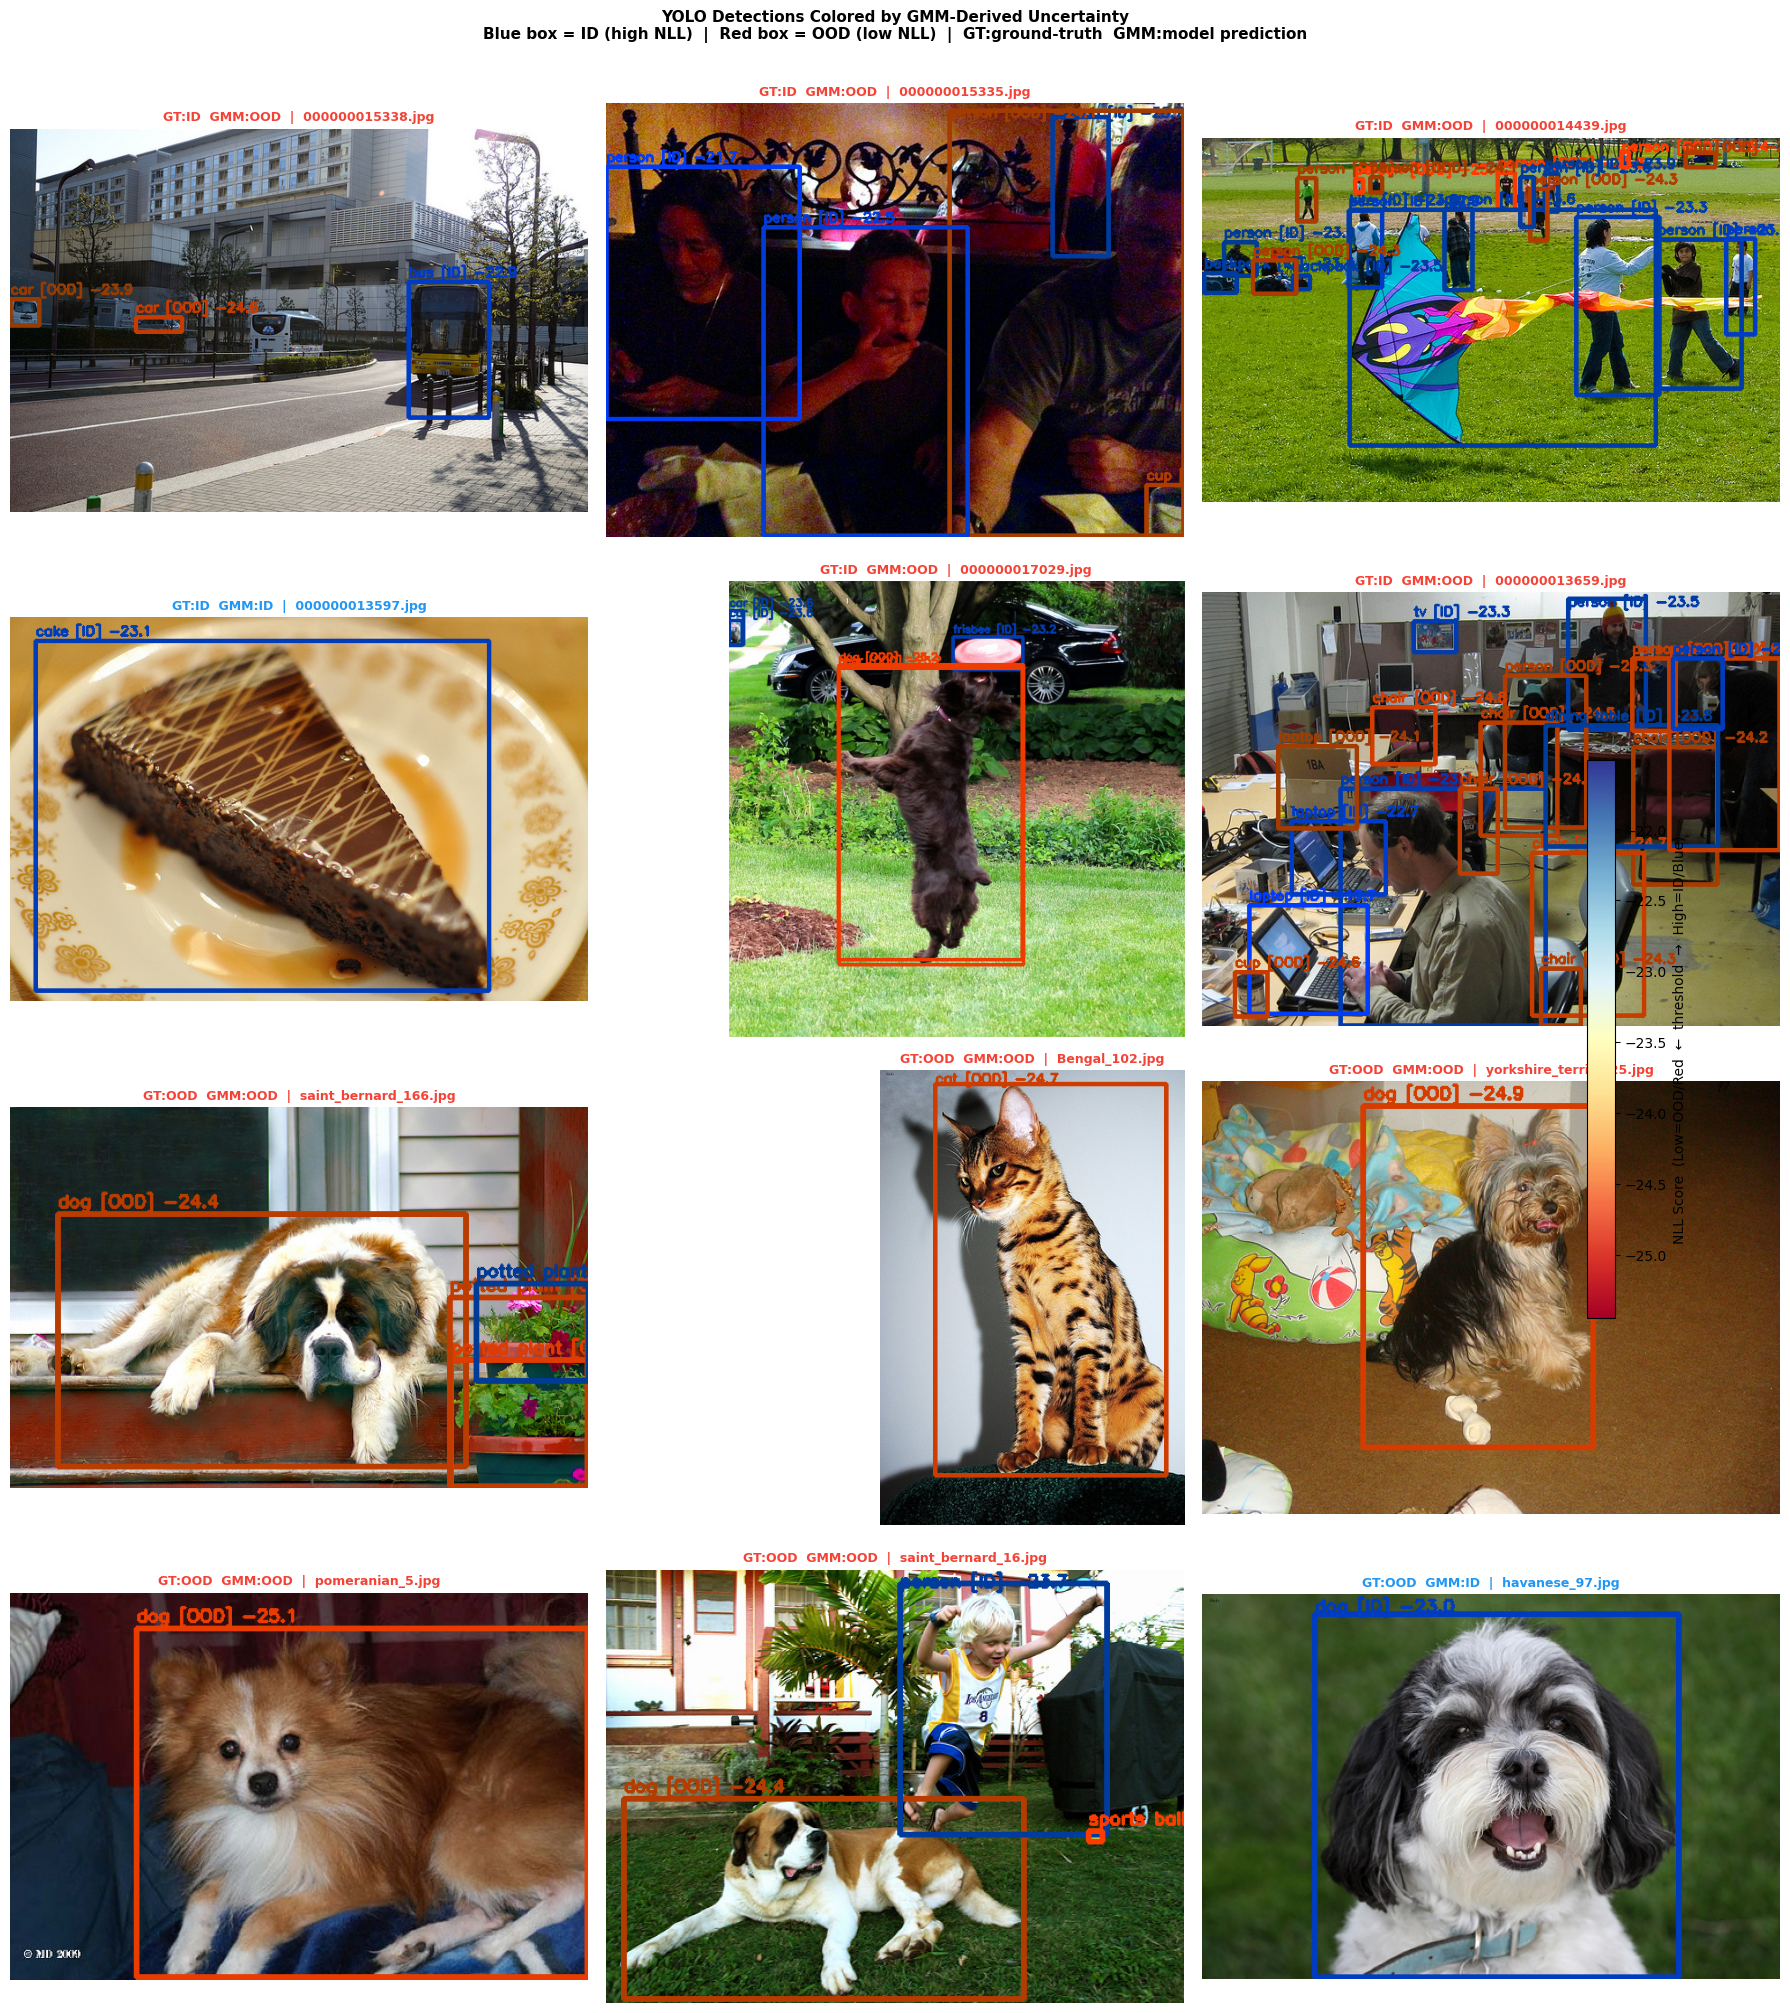

Saved: plot4_yolo_uncertainty.png

=========== SUMMARY ===========
Correct image-level decisions: 6/12 (50.0%)


In [ ]:
if len(vis_images) == 0:
    print("No visualization images generated. Check YOLO detections.")
else:
    ncols = min(3, len(vis_images))
    nrows = (len(vis_images) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    if nrows * ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    print("\n=========== GMM IMAGE-LEVEL REPORT ===========")
    total_images = 0
    correct = 0

    for idx, (vis, lbl, fname, box_labels) in enumerate(vis_images):
        r, c = divmod(idx, ncols)
        axes[r, c].imshow(vis)

        # FLIPPED: OOD = any box labeled "OOD" (i.e. low NLL)
        gmm_says_ood = any(b == "OOD" for b in box_labels) if box_labels else (lbl == "OOD")
        border_color = '#F44336' if gmm_says_ood else '#2196F3'
        gt_marker    = f"GT:{lbl}"
        gmm_marker   = f"GMM:{'OOD' if gmm_says_ood else 'ID'}"

        axes[r, c].set_title(f"{gt_marker}  {gmm_marker}  |  {fname[:25]}",
                             fontsize=9, color=border_color, fontweight='bold')
        for spine in axes[r, c].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        axes[r, c].axis('off')

        total_images += 1
        gmm_pred = "OOD" if gmm_says_ood else "ID"

        print(f"\nImage: {fname}")
        print(f"  Ground Truth : {lbl}")
        print(f"  Box decisions: {box_labels}")
        print(f"  GMM Decision : {gmm_pred}")
        print(f"  Result       : {'CORRECT' if gmm_pred == lbl else 'WRONG'}")
        if gmm_pred == lbl:
            correct += 1

    for idx in range(len(vis_images), nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].axis('off')

    cmap = plt.cm.RdYlBu   # FLIPPED colormap: blue=high NLL=ID, red=low NLL=OOD
    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=NLL_MIN, vmax=NLL_MAX))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label('NLL Score  (Low=OOD/Red  ←  threshold  →  High=ID/Blue)', fontsize=10)
    cbar.ax.axhline(y=(threshold - NLL_MIN) / (NLL_MAX - NLL_MIN),
                    color='black', linewidth=2, linestyle='--')

    fig.suptitle(
        "YOLO Detections Colored by GMM-Derived Uncertainty\n"
        "Blue box = ID (high NLL)  |  Red box = OOD (low NLL)  |  "
        "GT:ground-truth  GMM:model prediction",
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("plot4_yolo_uncertainty.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: plot4_yolo_uncertainty.png")

    print("\n=========== SUMMARY ===========")
    print(f"Correct image-level decisions: {correct}/{total_images} "
          f"({100*correct/total_images:.1f}%)")

## Step 13 — Summary: Use Case Results

In [ ]:
from sklearn.metrics import roc_auc_score  # only used for final evaluation metric

y_true = np.array([0] * len(nll_id_test) + [1] * len(nll_ood))
y_score = np.concatenate([nll_id_test, nll_ood])

try:
    auroc = roc_auc_score(y_true, y_score)
except Exception:
    auroc = float('nan')

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print()
print("Use Case 1 — Density Estimation (MDN paper)")
print(f"  GMM components (K)       : {K}")
print(f"  EM converged at iteration: {len(gmm.log_likelihoods)}")
print(f"  Final log-likelihood     : {gmm.log_likelihoods[-1]:.2f}")
print()
print("Use Case 2 — OOD Detection (FDE paper)")
print(f"  ID Test  mean NLL: {nll_id_test.mean():.2f} ± {nll_id_test.std():.2f}")
print(f"  OOD      mean NLL: {nll_ood.mean():.2f} ± {nll_ood.std():.2f}")
print(f"  OOD threshold    : {threshold:.2f}  (mean + 2σ of ID train)")
print(f"  OOD recall       : {100*ood_flagged/len(nll_ood):.0f}%  ({ood_flagged}/{len(nll_ood)} OOD correctly flagged)")
print(f"  ID false positive: {100*id_flagged/len(nll_id_test):.0f}%  ({id_flagged}/{len(nll_id_test)} ID incorrectly flagged)")
print(f"  AUROC (ID vs OOD): {auroc:.3f}")
print()
print("Use Case 3 — Per-Detection Uncertainty (Bayesian DL paper)")
print(f"  NLL range used for color: [{NLL_MIN:.1f}, {NLL_MAX:.1f}]")
print(f"  Sample images visualized : {len(vis_images)}")
print()
print("Plots saved:")
for fname in ["plot1_em_convergence.png", "plot2_gmm_density.png",
              "plot3_nll_distribution.png", "plot4_yolo_uncertainty.png"]:
    print(f"  {fname}")
print("=" * 60)

RESULTS SUMMARY

Use Case 1 — Density Estimation (MDN paper)
  GMM components (K)       : 3
  EM converged at iteration: 16
  Final log-likelihood     : 820.04

Use Case 2 — OOD Detection (FDE paper)
  ID Test  mean NLL: -23.68 ± 0.99
  OOD      mean NLL: -24.11 ± 1.13
  OOD threshold    : -23.92  (mean + 2σ of ID train)
  OOD recall       : 70%  (21/30 OOD correctly flagged)
  ID false positive: 40%  (4/10 ID incorrectly flagged)
  AUROC (ID vs OOD): 0.343

Use Case 3 — Per-Detection Uncertainty (Bayesian DL paper)
  NLL range used for color: [-25.4, -21.5]
  Sample images visualized : 12

Plots saved:
  plot1_em_convergence.png
  plot2_gmm_density.png
  plot3_nll_distribution.png
  plot4_yolo_uncertainty.png


---
## Appendix: GMM Sanity Check on Synthetic 2D Data

Validates the from-scratch GMM + EM implementation on a controlled mixture of 3 Gaussians.

  EM converged at iteration 18


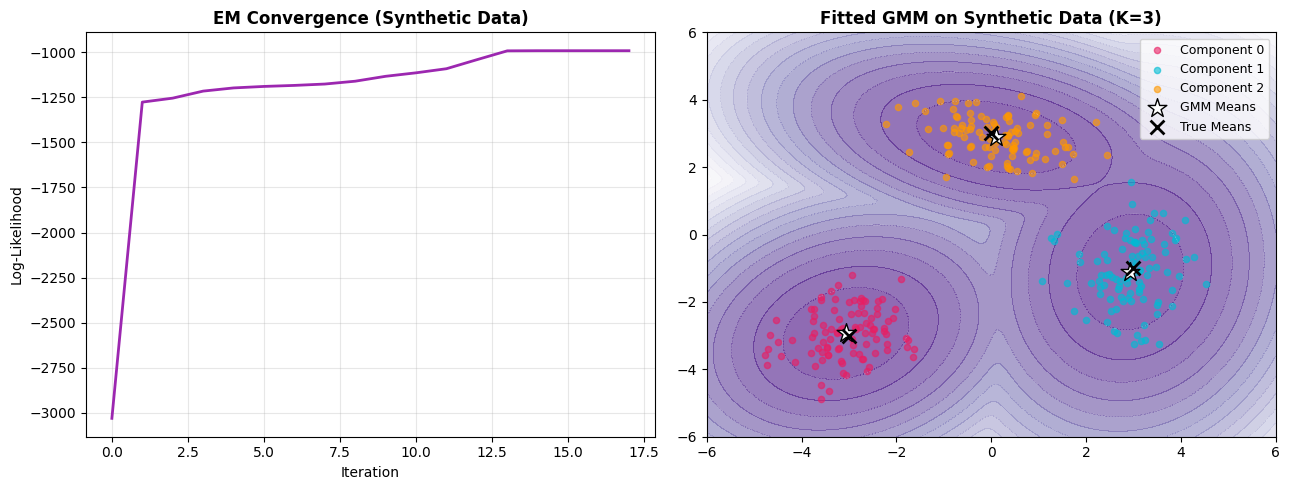

Sanity check passed. GMM correctly recovers synthetic components.


In [ ]:
# Generate synthetic 3-component GMM data
rng = np.random.RandomState(0)
N_synth = 300
means_true = np.array([[-3, -3], [0, 3], [3, -1]])
X_synth = np.vstack([
    rng.multivariate_normal(means_true[0], [[0.5, 0.1], [0.1, 0.5]], N_synth // 3),
    rng.multivariate_normal(means_true[1], [[0.8, -0.2], [-0.2, 0.4]], N_synth // 3),
    rng.multivariate_normal(means_true[2], [[0.4, 0.0], [0.0, 0.9]], N_synth // 3),
])
labels_true = np.array([0]*(N_synth//3) + [1]*(N_synth//3) + [2]*(N_synth//3))

gmm_synth = GMMFromScratch(n_components=3, max_iter=200, tol=1e-6, reg_covar=1e-4)
gmm_synth.fit(X_synth)
labels_pred = gmm_synth.predict(X_synth)

# Density grid
xg = np.linspace(-6, 6, 150)
yg = np.linspace(-6, 6, 150)
xx, yy = np.meshgrid(xg, yg)
grid_s = np.c_[xx.ravel(), yy.ravel()]
Zg = gmm_synth.score_samples(grid_s).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: EM convergence
axes[0].plot(gmm_synth.log_likelihoods, color='#9C27B0', linewidth=2)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Log-Likelihood")
axes[0].set_title("EM Convergence (Synthetic Data)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: Fitted GMM density
colors = ['#E91E63', '#00BCD4', '#FF9800']
axes[1].contourf(xx, yy, Zg, levels=20, cmap='Purples', alpha=0.6)
axes[1].contour(xx, yy, Zg, levels=8, colors='white', linewidths=0.4, alpha=0.5)
for k in range(3):
    mask = labels_pred == k
    axes[1].scatter(X_synth[mask, 0], X_synth[mask, 1], s=20, color=colors[k],
                    alpha=0.6, label=f'Component {k}')
axes[1].scatter(gmm_synth.mu[:, 0], gmm_synth.mu[:, 1], c='white', s=200,
                marker='*', edgecolors='black', zorder=5, label='GMM Means')
axes[1].scatter(means_true[:, 0], means_true[:, 1], c='black', s=100,
                marker='x', linewidths=2, zorder=6, label='True Means')
axes[1].set_title("Fitted GMM on Synthetic Data (K=3)", fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("appendix_gmm_sanity.png", dpi=150)
plt.show()
print("Sanity check passed. GMM correctly recovers synthetic components.")